In [75]:
#Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import zscore

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']
print("✅ Setup complete. All outputs will display inline in this notebook.")

#Load Data
FILE_PATH =(r"C:\Users\Taizeen\Downloads\data science assignments\Clustering\Clustering\EastWestAirlines.xlsx")

df_raw = pd.read_excel(FILE_PATH, sheet_name='data')
print(f"✅ Data loaded successfully!")
print(f"   Rows: {df_raw.shape[0]}   Columns: {df_raw.shape[1]}")
df_raw.head(10)

# Data Types & Missing Values
print("=" * 45)
print("  DATA TYPES")
print("=" * 45)
print(df_raw.dtypes)

print("\n" + "=" * 45)
print("  MISSING VALUES")
print("=" * 45)
print(df_raw.isnull().sum())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()}")

# Summary Statistics
print("Summary Statistics:")
df_raw.describe().round(2)

# Define Features
FEATURES = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
            'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

df = df_raw[FEATURES].copy()
print(f"✅ Features selected: {len(FEATURES)}")
print(FEATURES)

✅ Setup complete. All outputs will display inline in this notebook.
✅ Data loaded successfully!
   Rows: 3999   Columns: 12
  DATA TYPES
ID#                  int64
Balance              int64
Qual_miles           int64
cc1_miles            int64
cc2_miles            int64
cc3_miles            int64
Bonus_miles          int64
Bonus_trans          int64
Flight_miles_12mo    int64
Flight_trans_12      int64
Days_since_enroll    int64
Award?               int64
dtype: object

  MISSING VALUES
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Total missing: 0
Summary Statistics:
✅ Features selected: 10
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']


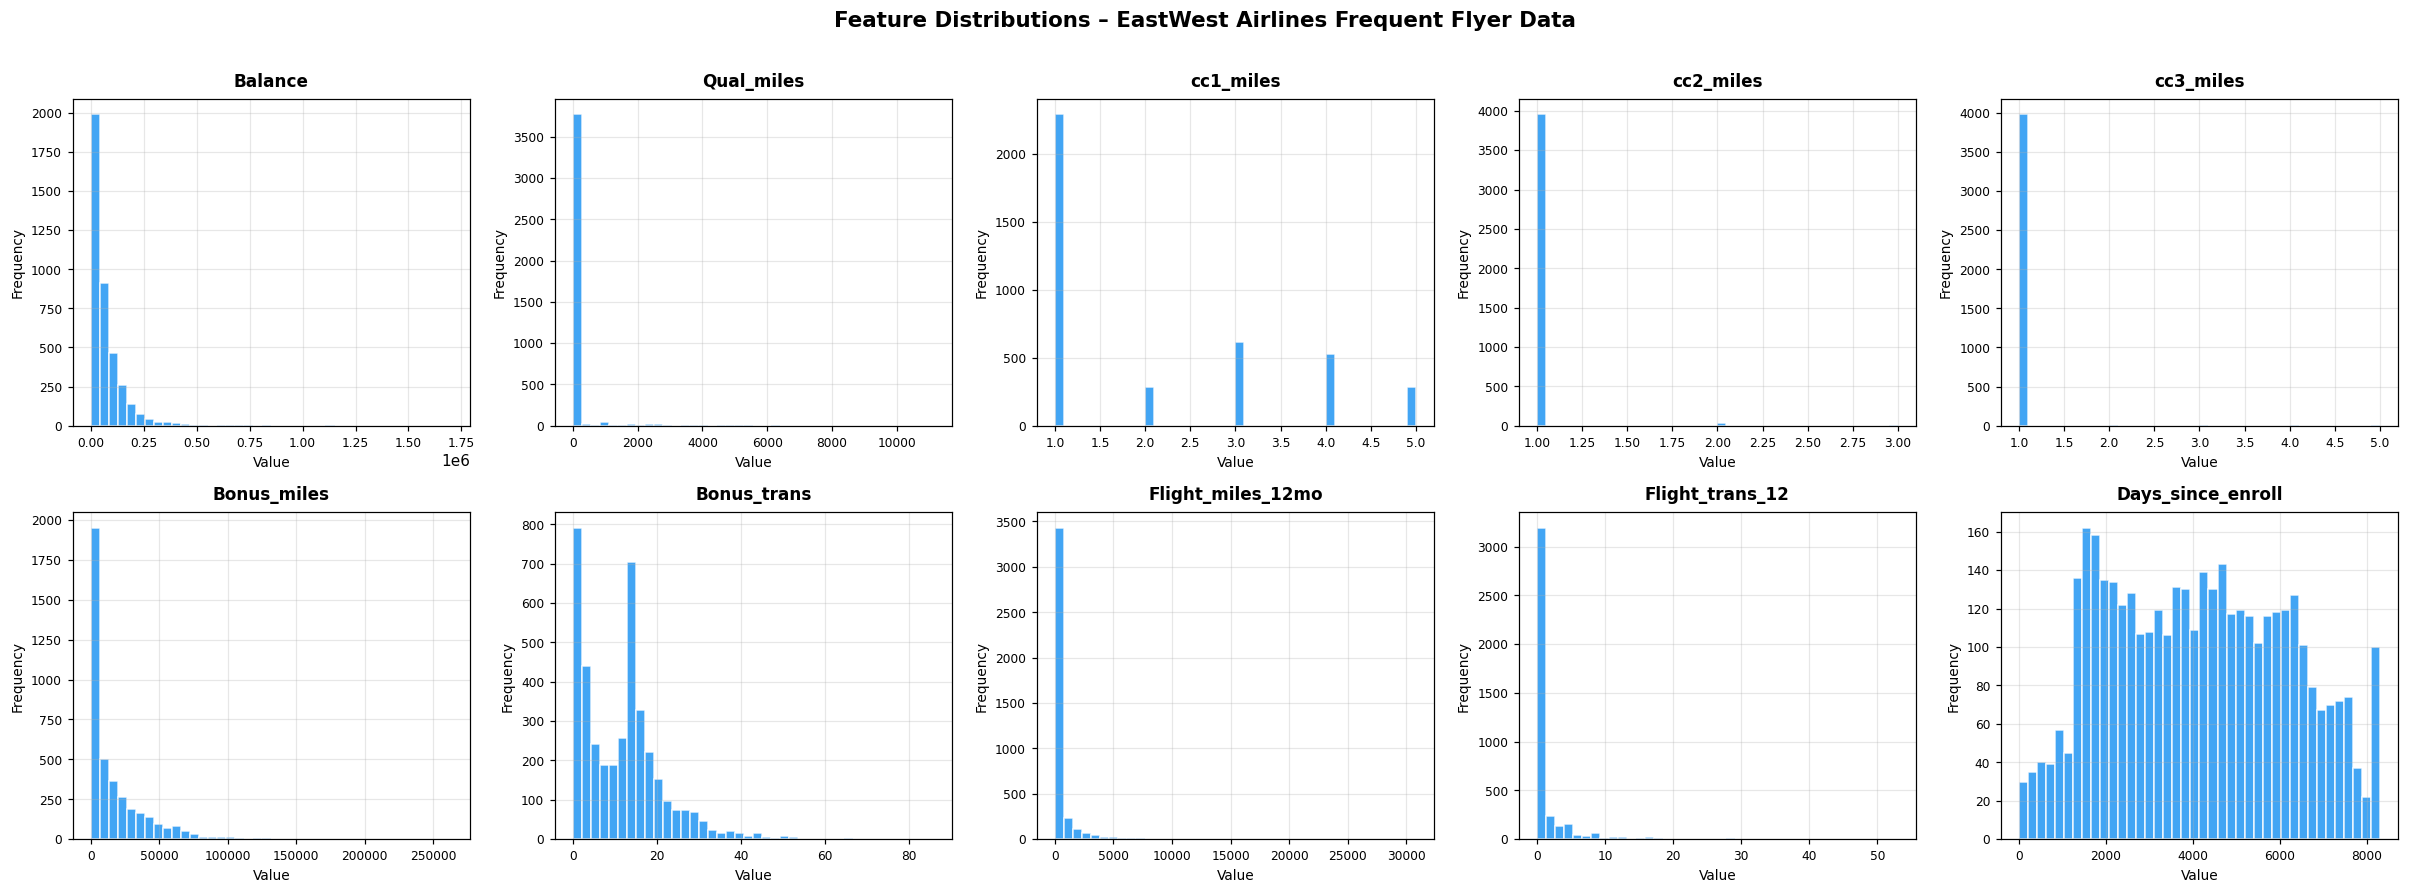

In [76]:
#EDA: Feature Distributions
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].tick_params(labelsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions – EastWest Airlines Frequent Flyer Data',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

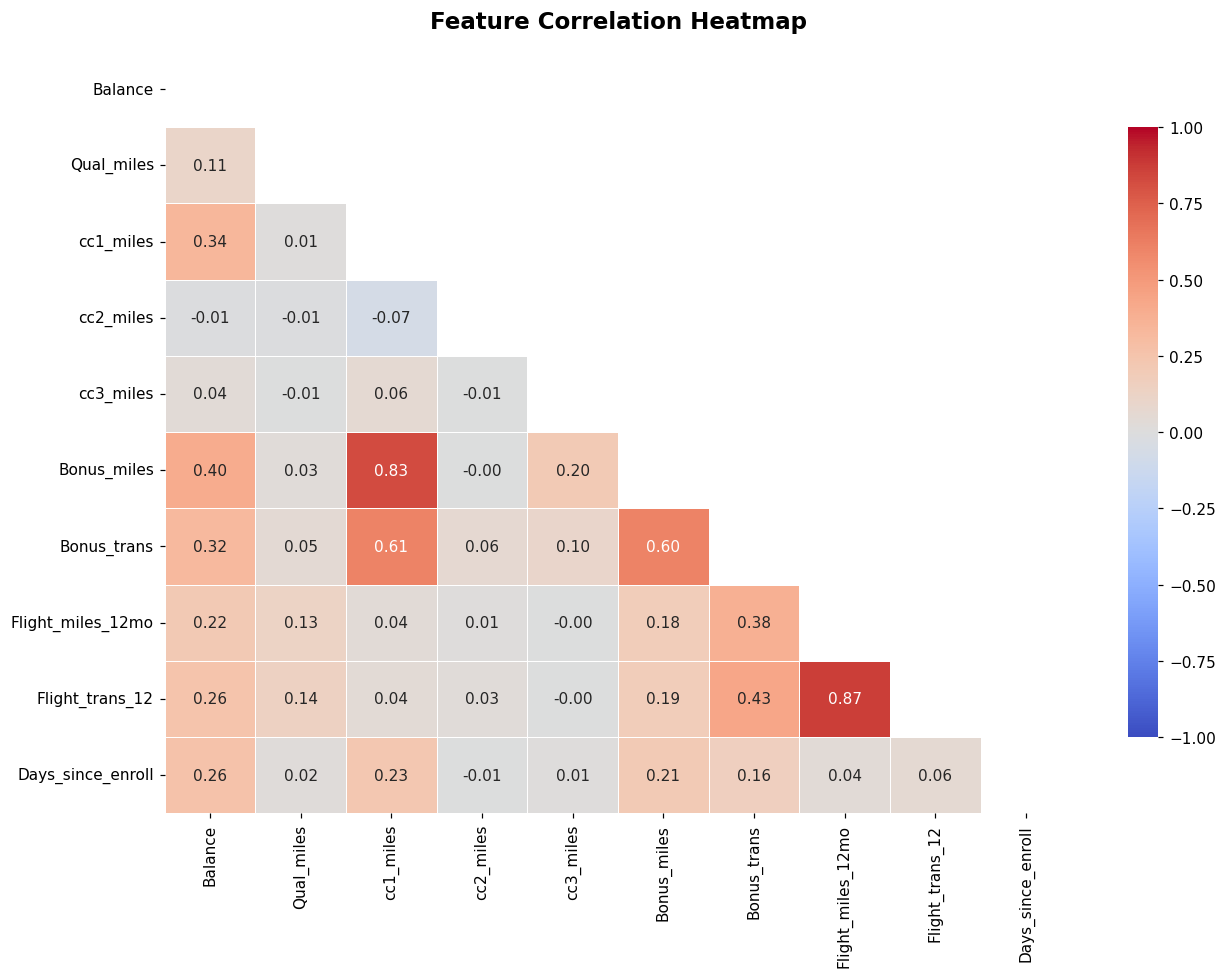

In [77]:
#Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10}, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

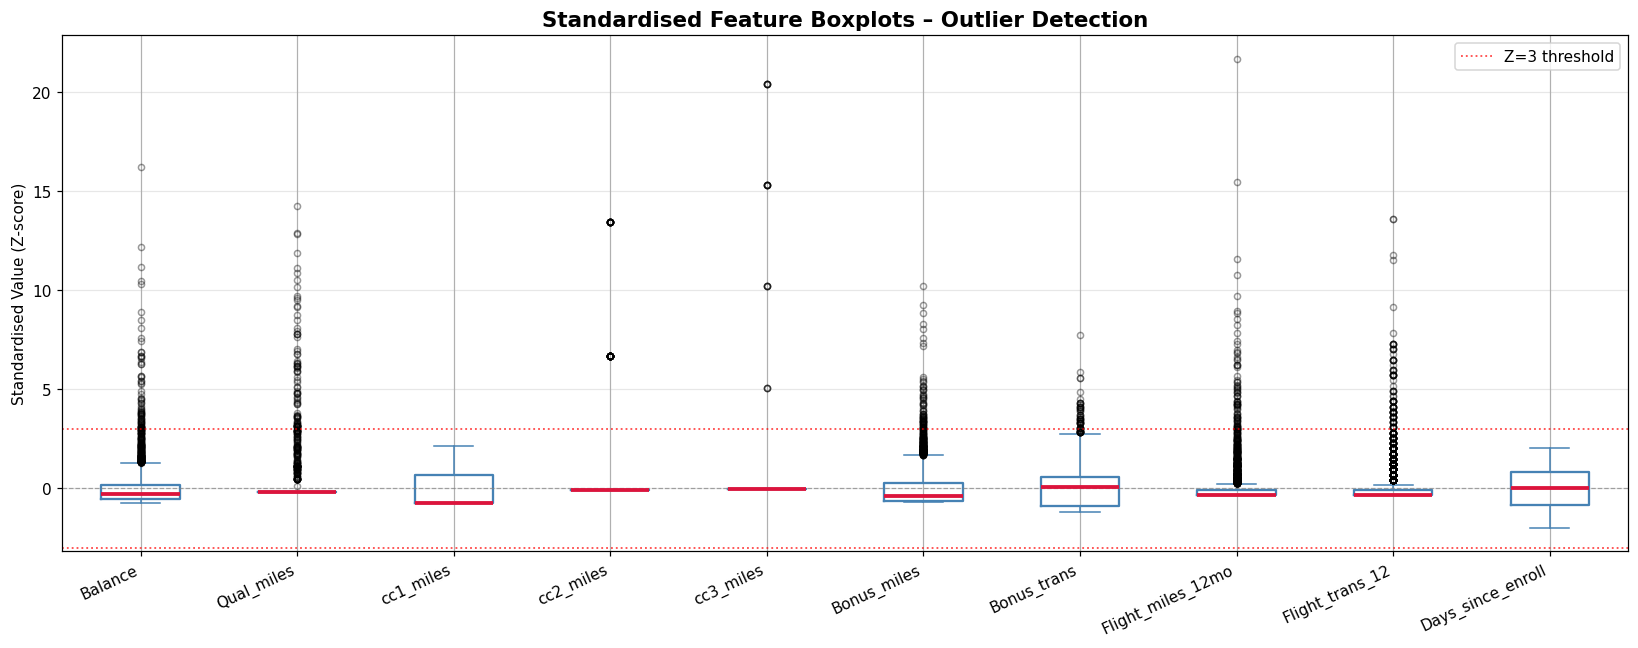

In [78]:
#Boxplots
df_std_vis = pd.DataFrame(StandardScaler().fit_transform(df), columns=FEATURES)

fig, ax = plt.subplots(figsize=(15, 6))
df_std_vis.boxplot(ax=ax, vert=True,
                   boxprops=dict(color='steelblue', linewidth=1.5),
                   medianprops=dict(color='crimson', linewidth=2.5),
                   whiskerprops=dict(color='steelblue'),
                   capprops=dict(color='steelblue'),
                   flierprops=dict(marker='o', color='orange', alpha=0.4, markersize=4))

ax.set_title('Standardised Feature Boxplots – Outlier Detection', fontsize=14, fontweight='bold')
ax.set_xticklabels(FEATURES, rotation=25, ha='right', fontsize=10)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(3, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='Z=3 threshold')
ax.axhline(-3, color='red', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_ylabel('Standardised Value (Z-score)')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
z_scores = np.abs(zscore(df))
mask_out = (z_scores < 3).all(axis=1)
df_clean = df[mask_out].copy()

print("=" * 45)
print("  PREPROCESSING SUMMARY")
print("=" * 45)
print(f"  Original rows     : {df.shape[0]}")
print(f"  After cleaning    : {df_clean.shape[0]}")
print(f"  Outliers removed  : {df.shape[0] - df_clean.shape[0]}  ({(df.shape[0]-df_clean.shape[0])/df.shape[0]*100:.1f}%)")

scaler = StandardScaler()
X = scaler.fit_transform(df_clean)
print(f"\n  ✅ Features standardised (mean=0, std=1)")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
print(f"\n  PCA (for visualisation only):")
print(f"    PC1 : {explained[0]*100:.1f}% variance")
print(f"    PC2 : {explained[1]*100:.1f}% variance")
print(f"    Total: {sum(explained)*100:.1f}% variance captured")



  PREPROCESSING SUMMARY
  Original rows     : 3999
  After cleaning    : 3630
  Outliers removed  : 369  (9.2%)

  ✅ Features standardised (mean=0, std=1)

  PCA (for visualisation only):
    PC1 : 37.2% variance
    PC2 : 22.6% variance
    Total: 59.8% variance captured


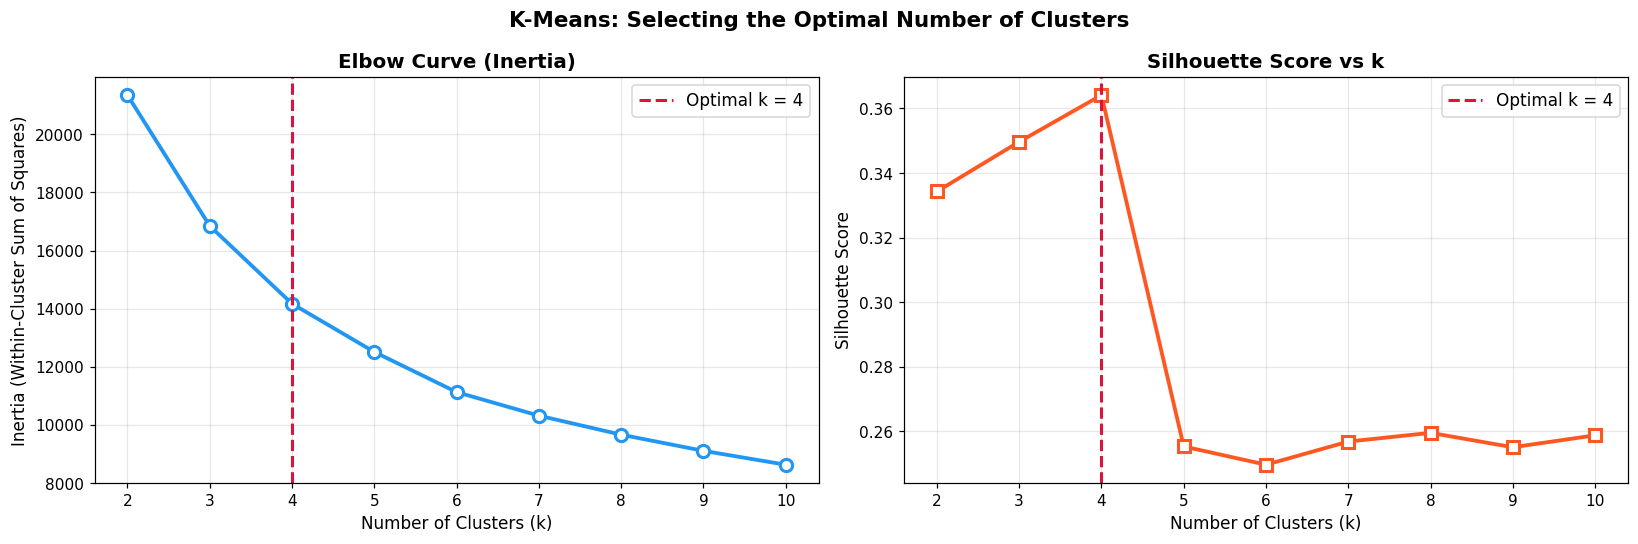


  k   Inertia     Silhouette
  ------------------------------
  2        21348   0.3343
  3        16847   0.3497
  4        14171   0.3641  ← Best
  5        12511   0.2553
  6        11129   0.2497
  7        10319   0.2568
  8         9665   0.2595
  9         9108   0.2551
  10         8631   0.2588


In [80]:
inertias, sil_scores_km = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0],
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(4, color='crimson', linestyle='--', linewidth=2, label='Optimal k = 4')
axes[0].set_title('Elbow Curve (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(K_range))


# Silhouette score
axes[1].plot(list(K_range), sil_scores_km, 's-', color=PALETTE[1],
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(4, color='crimson', linestyle='--', linewidth=2, label='Optimal k = 4')
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(K_range))

plt.suptitle('K-Means: Selecting the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print scores table
print("\n  k   Inertia     Silhouette")
print("  " + "-" * 30)
for k, (inn, sil) in enumerate(zip(inertias, sil_scores_km), start=2):
    marker = "  ← Best" if k == 4 else ""
    print(f"  {k}   {inn:>10.0f}   {sil:.4f}{marker}")

✅ K-Means (k=4) Silhouette Score: 0.3641


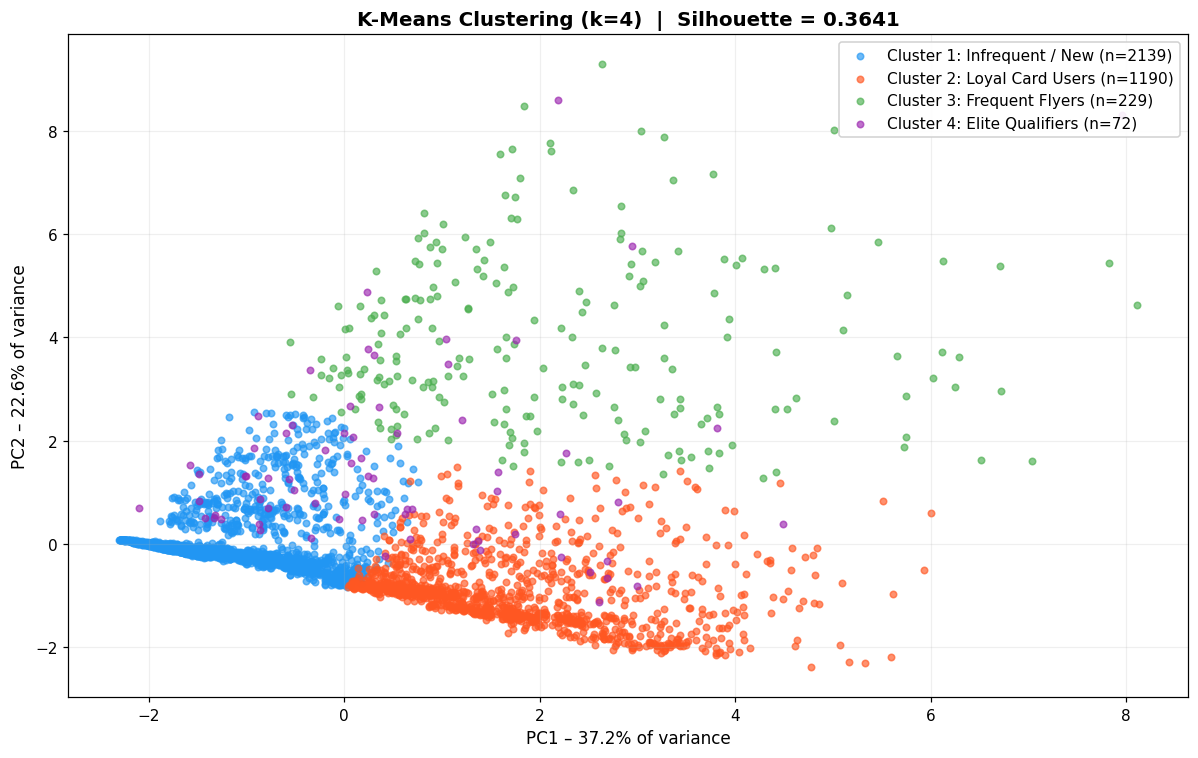

In [81]:
#K-Means
K_BEST = 4
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X)
km_sil = silhouette_score(X, km_labels)

print(f"✅ K-Means (k=4) Silhouette Score: {km_sil:.4f}")

fig, ax = plt.subplots(figsize=(11, 7))
cluster_names = ['Infrequent / New', 'Loyal Card Users', 'Frequent Flyers', 'Elite Qualifiers']

for c in range(K_BEST):
    mask = km_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=18, alpha=0.65, color=PALETTE[c],
               label=f'Cluster {c+1}: {cluster_names[c]} (n={mask.sum()})')

ax.set_title(f'K-Means Clustering (k={K_BEST})  |  Silhouette = {km_sil:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 – {explained[0]*100:.1f}% of variance', fontsize=11)
ax.set_ylabel(f'PC2 – {explained[1]*100:.1f}% of variance', fontsize=11)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

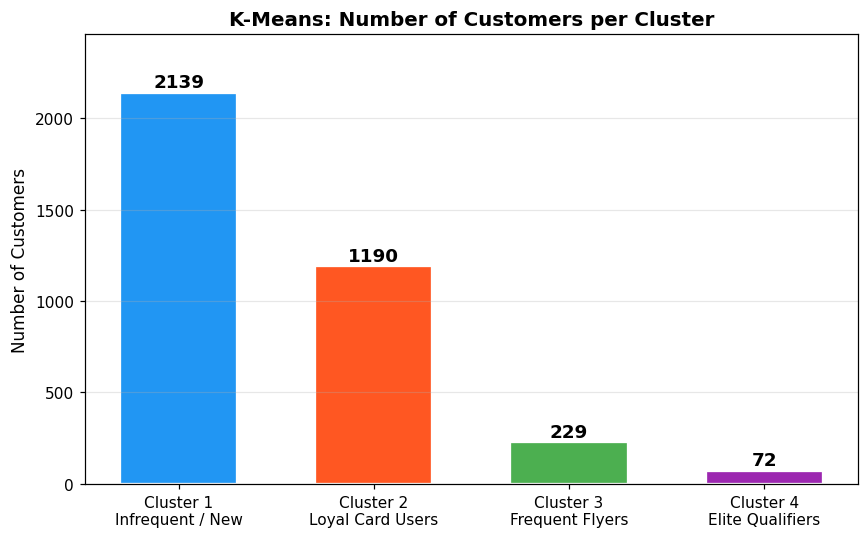

In [82]:

#K-Means
km_sizes = pd.Series(km_labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'Cluster {i+1}\n{cluster_names[i]}' for i in range(K_BEST)],
              [km_sizes[i] for i in range(K_BEST)],
              color=PALETTE[:K_BEST], edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, [km_sizes[i] for i in range(K_BEST)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('K-Means: Number of Customers per Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, max(km_sizes) * 1.15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

K-Means Cluster Feature Profiles (Raw Means):
                      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll
C1: Infrequent / New  36200.1         3.2        1.1        1.0        1.0       3548.1          5.9               97.1              0.3             3660.0
C2: Loyal Card Users  96017.5         6.1        3.5        1.0        1.0      32613.4         17.4              144.1              0.5             4723.6
C3: Frequent Flyers   97769.3        57.7        2.1        1.0        1.0      19563.9         16.3             2255.2              6.3             4314.0
C4: Elite Qualifiers  77825.8      1617.6        1.8        1.0        1.0      14258.2         10.8              461.9              1.5             4258.1


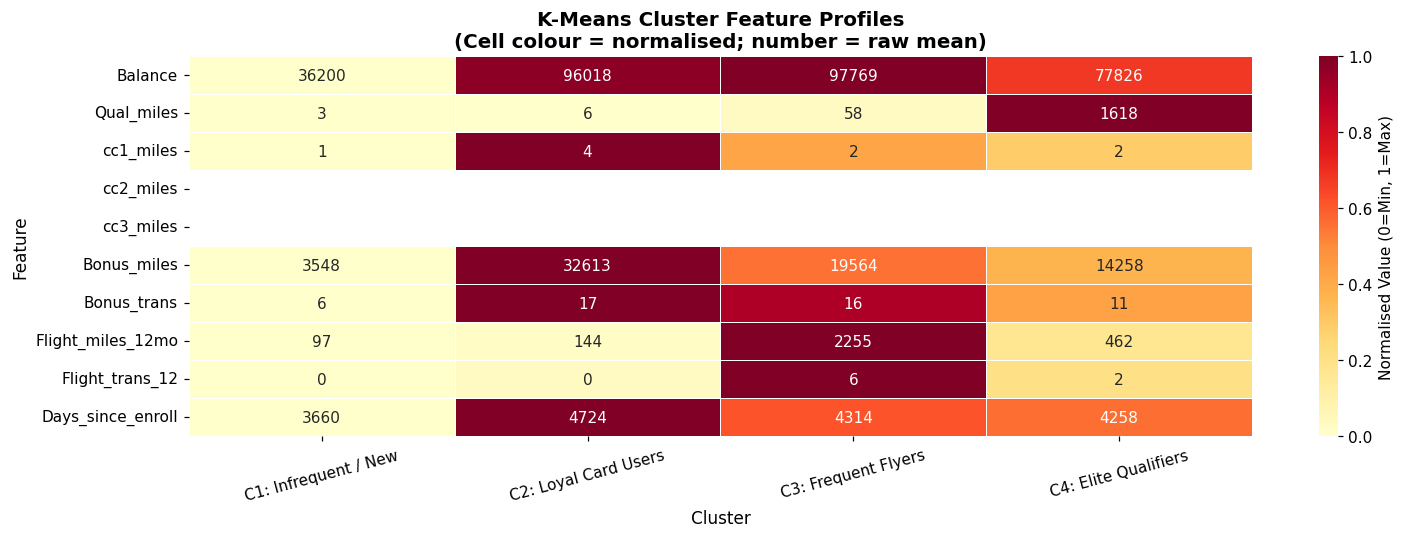

In [83]:

#K-Means: 
df_profile = df_clean.copy()
df_profile['KMeans_Cluster'] = km_labels + 1
km_profile = df_profile.groupby('KMeans_Cluster')[FEATURES].mean().round(1)
km_profile.index = [f'C{i}: {cluster_names[i-1]}' for i in km_profile.index]

print("K-Means Cluster Feature Profiles (Raw Means):")
print(km_profile.to_string())

# Normalise for heatmap colour scale
km_norm = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min())

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(km_norm.T, annot=km_profile.T.round(0), fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised Value (0=Min, 1=Max)'},
            annot_kws={'size': 10})
ax.set_title('K-Means Cluster Feature Profiles\n(Cell colour = normalised; number = raw mean)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


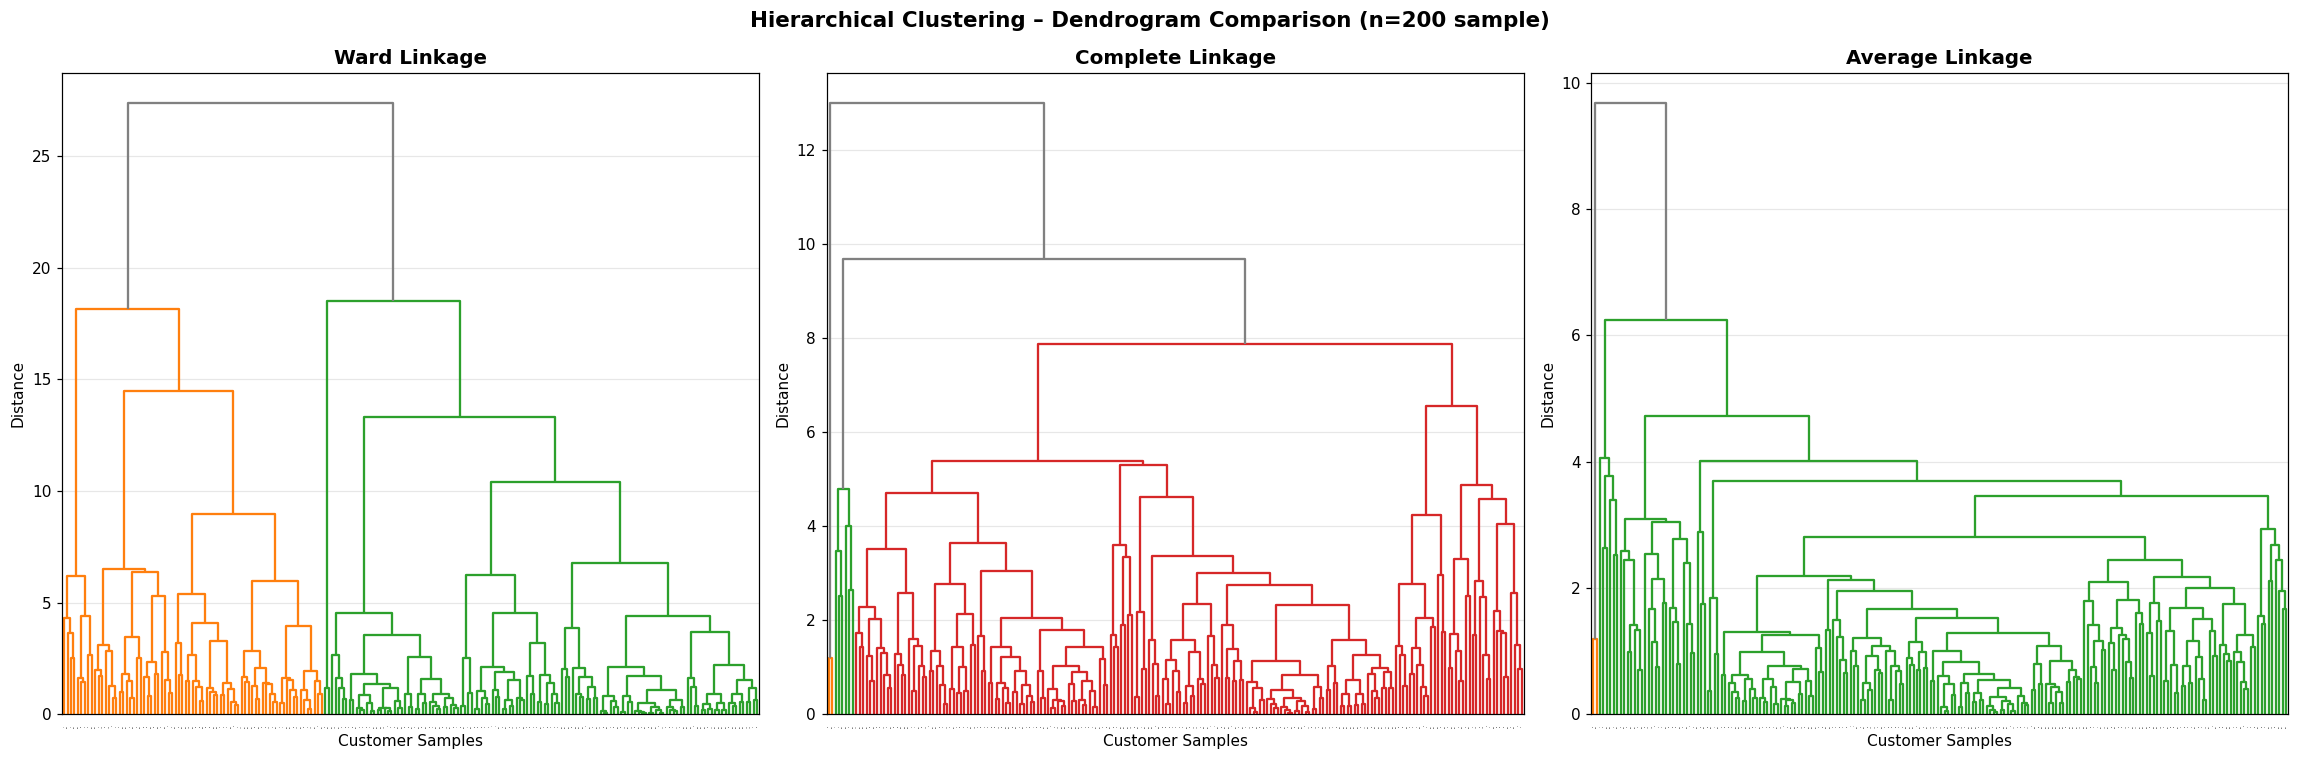

In [84]:
#Hierarchical
np.random.seed(42)
idx_sample = np.random.choice(len(X), 200, replace=False)
X_sample = X[idx_sample]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax,
               color_threshold=0.7 * max(Z[:, 2]),
               above_threshold_color='gray',
               leaf_font_size=0)
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=13, fontweight='bold')
    ax.set_xlabel('Customer Samples', fontsize=10)
    ax.set_ylabel('Distance', fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Hierarchical Clustering – Dendrogram Comparison (n=200 sample)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

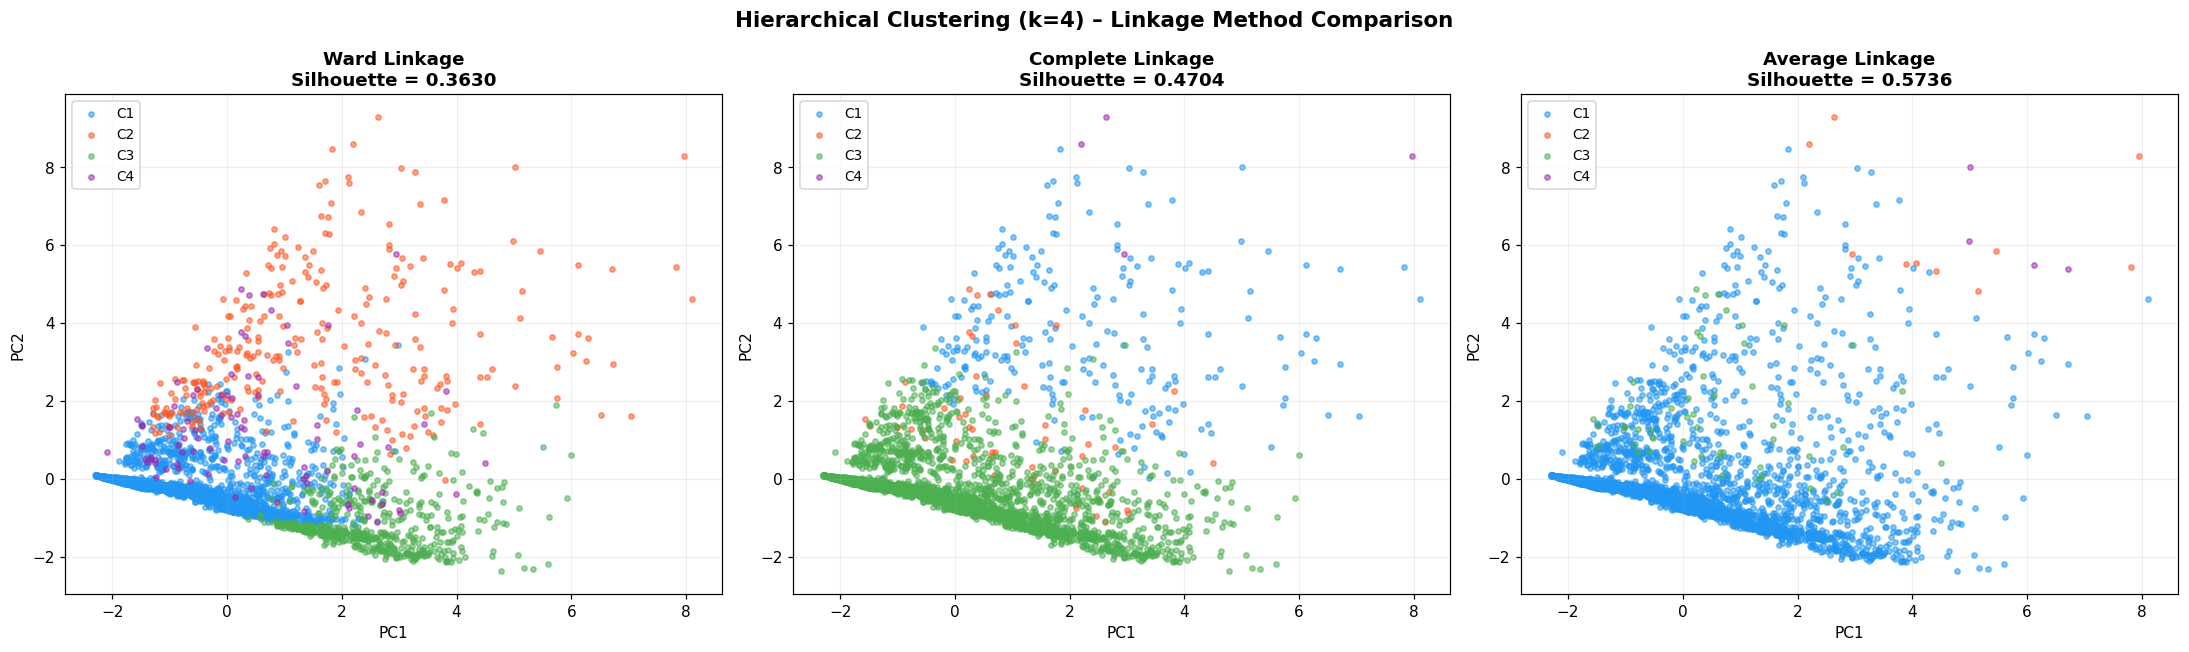


  Linkage      Silhouette Score
  --------------------------------
  ward         0.3630  ← Best
  complete     0.4704
  average      0.5736


In [85]:


#Hierarchical
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sil_scores_hc = {}

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    hc_tmp = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels_tmp = hc_tmp.fit_predict(X)
    sil_tmp = silhouette_score(X, labels_tmp)
    sil_scores_hc[method] = sil_tmp


    for c in range(4):
        mask = labels_tmp == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=12, alpha=0.55, color=PALETTE[c], label=f'C{c+1}')

    ax.set_title(f'{method.capitalize()} Linkage\nSilhouette = {sil_tmp:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Hierarchical Clustering (k=4) – Linkage Method Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Save ward labels for comparison
hc_final = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc_final.fit_predict(X)
hc_sil = silhouette_score(X, hc_labels)

print("\n  Linkage      Silhouette Score")
print("  " + "-" * 32)
for method, sil in sil_scores_hc.items():
    marker = "  ← Best" if method == 'ward' else ""
    print(f"  {method:<12} {sil:.4f}{marker}")

In [86]:

#DBSCAN:
params = [(0.8, 5), (1.0, 5), (1.2, 5), (1.0, 10), (1.0, 15), (1.5, 5)]
dbscan_results = []

for eps, mpts in params:
    db = DBSCAN(eps=eps, min_samples=mpts)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    sil = silhouette_score(X, labels) if n_clusters > 1 else np.nan
    dbscan_results.append({
        'Epsilon': eps,
        'min_samples': mpts,
        'Clusters Found': n_clusters,
        'Noise Points': n_noise,
        'Noise %': f"{n_noise/len(labels)*100:.1f}%",
        'Silhouette': round(sil, 4) if not np.isnan(sil) else 'N/A'
    })

dbscan_df = pd.DataFrame(dbscan_results)
print("DBSCAN Parameter Tuning Results:")
dbscan_df

DBSCAN Parameter Tuning Results:


,Epsilon,min_samples,Clusters Found,Noise Points,Noise %,Silhouette
0,0.8,5,6,676,18.6%,0.1201
1,1.0,5,3,464,12.8%,0.2319
2,1.2,5,3,322,8.9%,0.2892
3,1.0,10,1,567,15.6%,N/A
4,1.0,15,1,642,17.7%,N/A
5,1.5,5,3,188,5.2%,0.2931


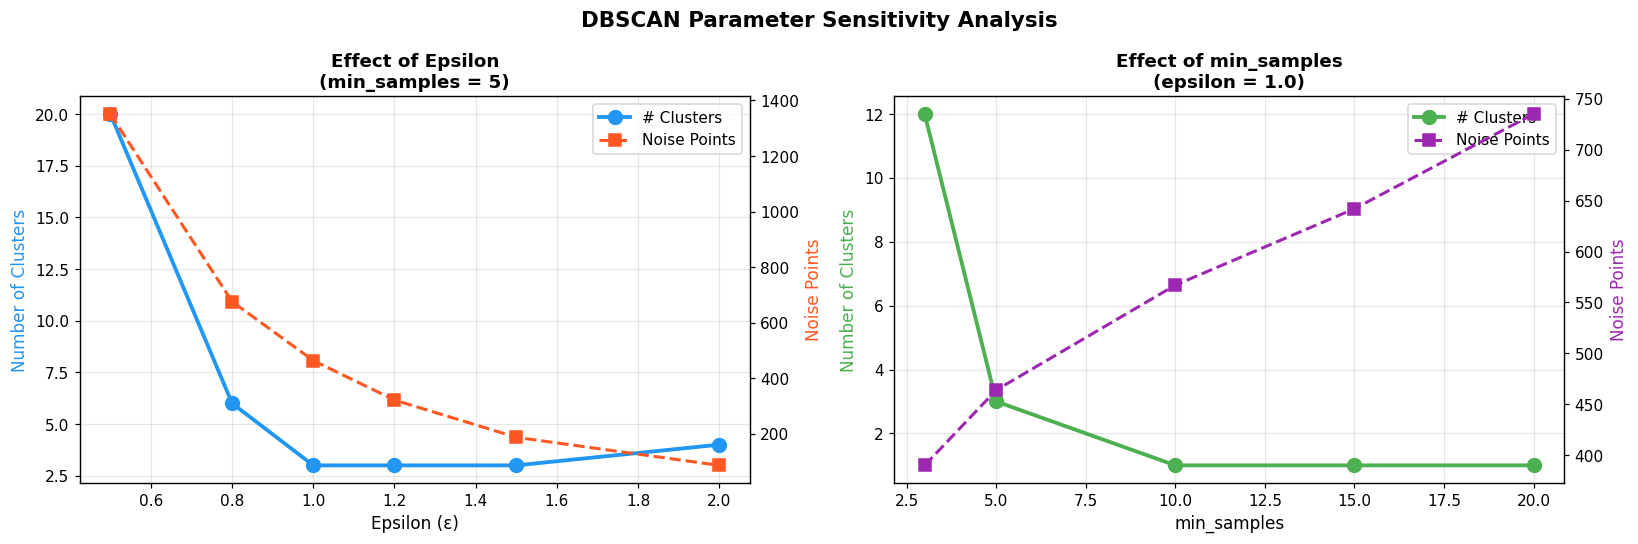

In [87]:

# - DBSCAN
eps_vals  = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
mpts_vals = [3, 5, 10, 15, 20]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Vary epsilon
nclusters_eps, noise_eps = [], []
for e in eps_vals:
    lb = DBSCAN(eps=e, min_samples=5).fit_predict(X)
    nclusters_eps.append(len(set(lb)) - (1 if -1 in lb else 0))
    noise_eps.append((lb == -1).sum())

ax1 = axes[0]
ax1b = ax1.twinx()
l1, = ax1.plot(eps_vals, nclusters_eps, 'o-', color=PALETTE[0], linewidth=2.5, markersize=9, label='# Clusters')
l2, = ax1b.plot(eps_vals, noise_eps, 's--', color=PALETTE[1], linewidth=2, markersize=8, label='Noise Points')
ax1.set_xlabel('Epsilon (ε)', fontsize=11)
ax1.set_ylabel('Number of Clusters', color=PALETTE[0], fontsize=11)
ax1b.set_ylabel('Noise Points', color=PALETTE[1], fontsize=11)
ax1.set_title('Effect of Epsilon\n(min_samples = 5)', fontsize=12, fontweight='bold')
ax1.legend(handles=[l1, l2], loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Vary min_samples
nclusters_mpts, noise_mpts = [], []
for m in mpts_vals:
    lb = DBSCAN(eps=1.0, min_samples=m).fit_predict(X)
    nclusters_mpts.append(len(set(lb)) - (1 if -1 in lb else 0))
    noise_mpts.append((lb == -1).sum())

ax2 = axes[1]
ax2b = ax2.twinx()
l3, = ax2.plot(mpts_vals, nclusters_mpts, 'o-', color=PALETTE[2], linewidth=2.5, markersize=9, label='# Clusters')
l4, = ax2b.plot(mpts_vals, noise_mpts, 's--', color=PALETTE[3], linewidth=2, markersize=8, label='Noise Points')
ax2.set_xlabel('min_samples', fontsize=11)
ax2.set_ylabel('Number of Clusters', color=PALETTE[2], fontsize=11)
ax2b.set_ylabel('Noise Points', color=PALETTE[3], fontsize=11)
ax2.set_title('Effect of min_samples\n(epsilon = 1.0)', fontsize=12, fontweight='bold')
ax2.legend(handles=[l3, l4], loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Parameter Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

DBSCAN Final Results (eps=1.0, min_samples=5):
  Clusters found : 3
  Noise points   : 464  (12.8% of data)
  Silhouette     : 0.2319


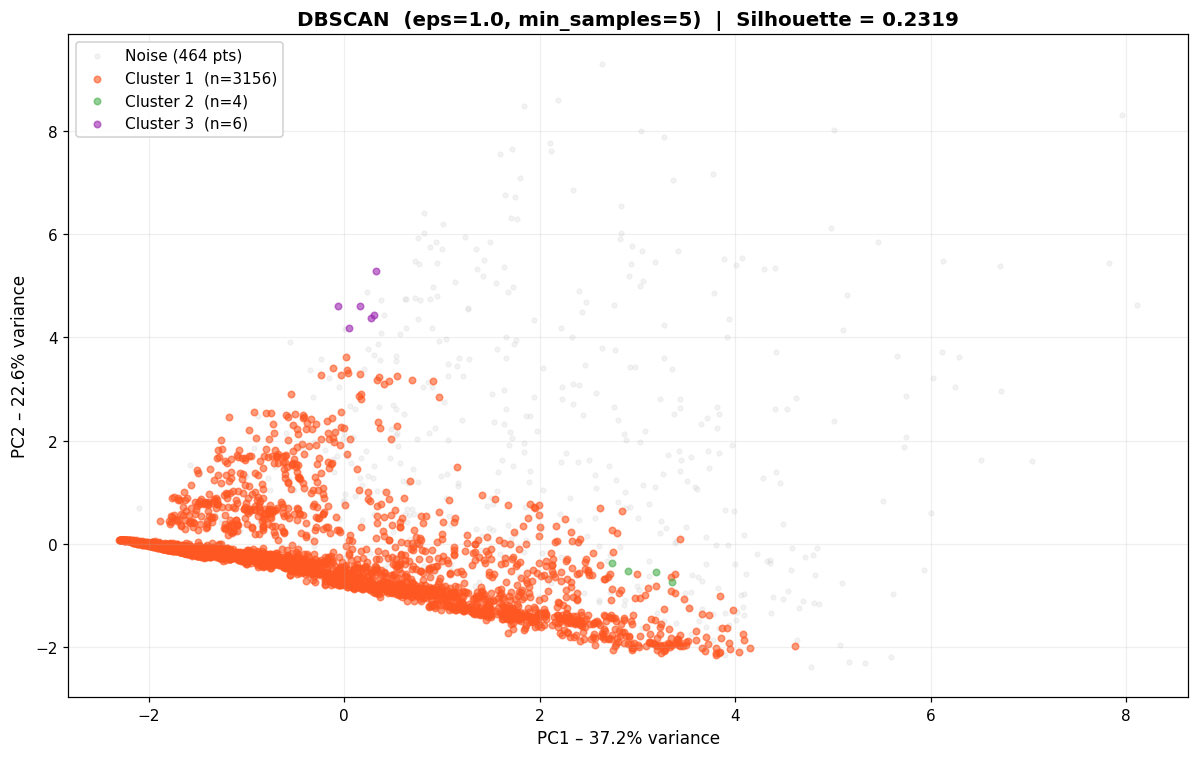

In [88]:

db_best   = DBSCAN(eps=1.0, min_samples=5)
db_labels = db_best.fit_predict(X)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
db_sil        = silhouette_score(X, db_labels) if n_db_clusters > 1 else np.nan
sil_str       = f'{db_sil:.4f}' if not np.isnan(db_sil) else 'N/A'

print(f"DBSCAN Final Results (eps=1.0, min_samples=5):")
print(f"  Clusters found : {n_db_clusters}")
print(f"  Noise points   : {n_noise}  ({n_noise/len(db_labels)*100:.1f}% of data)")
print(f"  Silhouette     : {sil_str}")

fig, ax = plt.subplots(figsize=(11, 7))
for i, lbl in enumerate(sorted(set(db_labels))):
    mask  = db_labels == lbl
    color = 'lightgray' if lbl == -1 else PALETTE[i % len(PALETTE)]
    lname = f'Noise ({n_noise} pts)' if lbl == -1 else f'Cluster {lbl+1}  (n={mask.sum()})'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=18 if lbl != -1 else 10,
               alpha=0.6 if lbl != -1 else 0.25,
               color=color, label=lname)

ax.set_title(f'DBSCAN  (eps=1.0, min_samples=5)  |  Silhouette = {sil_str}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 – {explained[0]*100:.1f}% variance', fontsize=11)
ax.set_ylabel(f'PC2 – {explained[1]*100:.1f}% variance', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [89]:
#- All Three Algorithms Side-by-Side

plot_configs = [
    (km_labels, f'K-Means  (k=4)\nSilhouette = {km_sil:.4f}'),
    (hc_labels, f'Hierarchical – Ward  (k=4)\nSilhouette = {hc_sil:.4f}'),
    (db_labels, f'DBSCAN  (eps=1.0, mpts=5)\nSilhouette = {sil_str}'),
]

for ax, (labels, title) in zip(axes, plot_configs):
    for i, lbl in enumerate(sorted(set(labels))):
        mask  = labels == lbl
        color = 'lightgray' if lbl == -1 else PALETTE[i % len(PALETTE)]
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl+1}  (n={mask.sum()})'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=12, alpha=0.5 if lbl != -1 else 0.2,
                   color=color, label=lname)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(True, alpha=0.2)

plt.suptitle('Clustering Algorithm Comparison – EastWest Airlines',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 704x528 with 0 Axes>

In [90]:
#Final Summary
print("=" * 55)
print("        FINAL CLUSTERING RESULTS SUMMARY")
print("=" * 55)
print(f"  {'Algorithm':<30} {'Silhouette':>12}")
print("  " + "-" * 43)
print(f"  {'K-Means (k=4)':<30} {km_sil:>12.4f}  ✅ Best")
print(f"  {'Hierarchical Ward (k=4)':<30} {hc_sil:>12.4f}")
print(f"  {'DBSCAN (eps=1.0, mpts=5)':<30} {sil_str:>12}")
print("=" * 55)

print("\n  K-Means Segment Summary:")
print("  " + "-" * 43)
for c, name in enumerate(cluster_names):
    size = (km_labels == c).sum()
    pct  = size / len(km_labels) * 100
    print(f"  Cluster {c+1} – {name:<25} {size:>5} customers  ({pct:.1f}%)")

print("\n✅ All outputs displayed inline. No files were saved.")

        FINAL CLUSTERING RESULTS SUMMARY
  Algorithm                        Silhouette
  -------------------------------------------
  K-Means (k=4)                        0.3641  ✅ Best
  Hierarchical Ward (k=4)              0.3630
  DBSCAN (eps=1.0, mpts=5)             0.2319

  K-Means Segment Summary:
  -------------------------------------------
  Cluster 1 – Infrequent / New           2139 customers  (58.9%)
  Cluster 2 – Loyal Card Users           1190 customers  (32.8%)
  Cluster 3 – Frequent Flyers             229 customers  (6.3%)
  Cluster 4 – Elite Qualifiers             72 customers  (2.0%)

✅ All outputs displayed inline. No files were saved.
